In [ ]:
!pip install -U spacy==3.*
!python -m spacy download en_core_web_sm
!python -m spacy info

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.

============================== Info about spaCy ==============================

spaCy version    3.8.11                        
Location         /usr/local/lib/python3.12/dist-packages/spacy
Platform         Linux-6.6.113+-x86_64-with-glibc2.35
Python version   3.12.12                       
Pipelines        en_core_web_sm (3.8.0)        



In [ ]:
# Upgrade gensim in case.
# !pip install --upgrade numpy
!pip install -U gensim==4.*

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import random
import spacy
import nltk
import re
import numpy as np

from nltk.stem import WordNetLemmatizer
from collections import Counter
from gensim import models, corpora
from gensim import similarities
from gensim.models.coherencemodel import CoherenceModel
from wordcloud import WordCloud

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"

locale.getpreferredencoding = getpreferredencoding

In [ ]:
!pip install --upgrade --no-cache-dir gdown

In [ ]:
# Download the CNN corpus.
!gdown 'https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf'

Downloading...
From (original): https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf
From (redirected): https://drive.google.com/uc?id=122fC9XpNwFKx0ryRVKJz5MWUTzA3Vpsf&confirm=t&uuid=26e923b8-b6b9-406d-861a-0927eac6718e
To: /content/cnn_articles.txt
100% 365M/365M [00:03<00:00, 106MB/s]


In [ ]:
with open('cnn_articles.txt', 'r', encoding='utf8') as f:
  articles = f.read().split('@delimiter')

In [ ]:
DATASET_SIZE = 54000
dataset = articles[:DATASET_SIZE]

In [ ]:
NUM_PROCESS = 4

In [ ]:
import re

tokenized_articles = []

for doc in dataset:
    tokens = re.findall(r"[a-zA-Z]+(?:'[a-z]+)?", doc.lower())
    tokens = [w.replace("'s","") for w in tokens]
    tokenized_articles.append(tokens)

In [ ]:
lemmatizer = WordNetLemmatizer()

processed_docs = [
    [lemmatizer.lemmatize(word, "v") for word in doc]
    for doc in tokenized_articles
]

In [ ]:
N = len(processed_docs)

# Total tokens
total_tokens = sum(len(doc) for doc in processed_docs)

# Vocabulary
vocab = set(word for doc in processed_docs for word in doc)
V = len(vocab)

# Document lengths
lengths = [len(doc) for doc in processed_docs if len(doc) != 0]

# Statistics
avg_length = np.mean(lengths)
std_length = np.std(lengths)

min_length = np.min(lengths)
max_length = np.max(lengths)

print("Number of documents (N):", N)
print("Total tokens:", total_tokens)
print("Vocabulary size (|V|):", V)
print("Average document length:", avg_length)
print("Std document length:", std_length)
print("Shortest document:", min_length)
print("Longest document:", max_length)

Number of documents (N): 54000
Total tokens: 34973691
Vocabulary size (|V|): 164541
Average document length: 648.525645304851
Std document length: 339.5819091555793
Shortest document: 5
Longest document: 1840


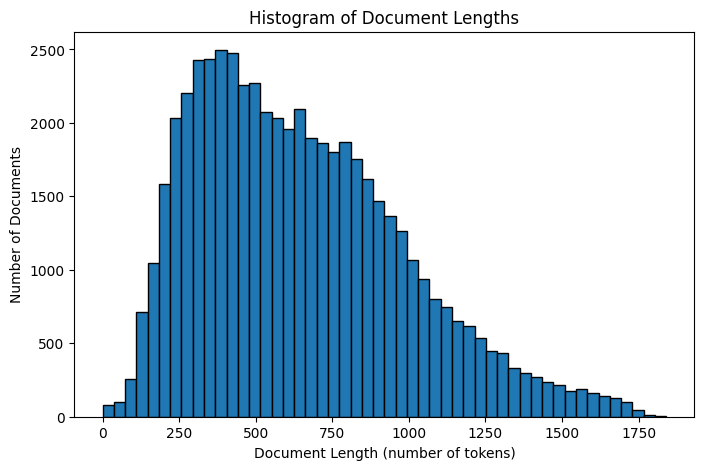

In [ ]:
lengths = [len(doc) for doc in processed_docs]

plt.figure(figsize=(8,5))
plt.hist(lengths, bins=50, edgecolor = 'black')
plt.xlabel("Document Length (number of tokens)")
plt.ylabel("Number of Documents")
plt.title("Histogram of Document Lengths")
plt.show()

In [ ]:
N = len(processed_docs)

short_20 = sum(1 for doc in processed_docs if len(doc) < 20)
short_50 = sum(1 for doc in processed_docs if len(doc) < 50)

print("Documents < 20 tokens:", short_20)
print("Documents < 50 tokens:", short_50)


Documents < 20 tokens: 76
Documents < 50 tokens: 106


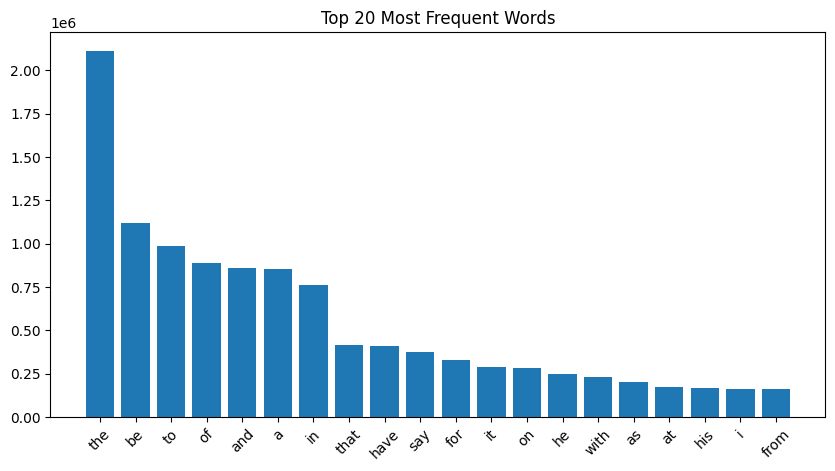

In [ ]:
all_words = [word for doc in processed_docs for word in doc]

word_freq = Counter(all_words)

top20 = word_freq.most_common(20)

words = [w for w, c in top20]
counts = [c for w, c in top20]

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

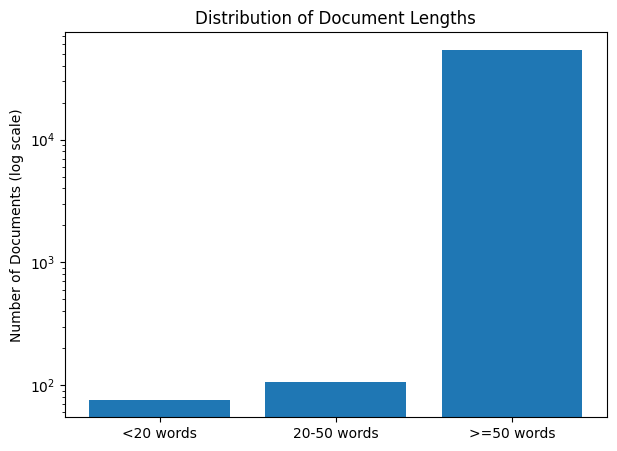

In [ ]:
lengths = [len(doc) for doc in processed_docs]

short = sum(l < 20 for l in lengths)
medium = sum(l < 50 for l in lengths)
long = sum(l >= 50 for l in lengths)

labels = ["<20 words", "20-50 words", ">=50 words"]
counts = [short, medium, long]

plt.figure(figsize=(7,5))

plt.bar(labels, counts)

plt.yscale("log")

plt.ylabel("Number of Documents (log scale)")
plt.title("Distribution of Document Lengths")

plt.show()

In [ ]:
N = len(processed_docs)

vocab = set(all_words)
V = len(vocab)

nonzero = sum(len(doc) for doc in processed_docs)

sparsity = 1 - (nonzero / (N * V))

print("Document-Term Matrix Sparsity:", sparsity)

Document-Term Matrix Sparsity: 0.9960638324524317


In [ ]:

all_words = [word for doc in processed_docs for word in doc]

vocab = set(all_words)

In [ ]:
num_unique_words = len(vocab)

print("Number of unique words:", num_unique_words)

Number of unique words: 164541


In [ ]:
word_lengths = [len(word) for word in vocab]

avg_word_length = np.mean(word_lengths)

print("Average word length:", avg_word_length)

Average word length: 7.530809950103621


In [ ]:
max_word_length = np.max(word_lengths)

print("Maximum word length:", max_word_length)

Maximum word length: 60


In [ ]:
estimated_nodes = sum(len(word) for word in vocab)

print("Estimated Trie nodes:", estimated_nodes)

Estimated Trie nodes: 1239127
